In [92]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [93]:
DIR = Path('/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full')

In [94]:
metagrads = np.load(DIR / 'metagrads.npy')

metagrads.shape

(12288000,)

In [90]:
metagrads.reshape(-1, 1024).max(1)[2200:]

array([5.2227435e-05, 6.4384927e-05, 4.7136196e-05, ..., 1.6242651e-04,
       1.7209238e-04, 1.2798724e-04], shape=(9800,), dtype=float32)

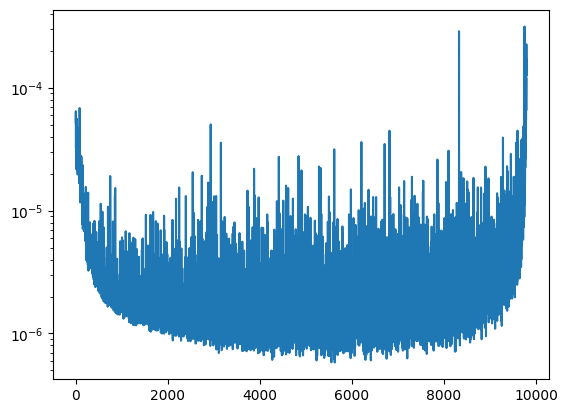

In [91]:
plt.plot(metagrads.reshape(-1, 1024).max(1)[2200:])
plt.yscale('log')

In [ ]:
np.where(metagrads != 0)[0] / 1024 # 1520 is where metagrads stopped

array([ 1520.        ,  1520.00097656,  1520.00195312, ...,
       11999.99707031, 11999.99804688, 11999.99902344], shape=(10731520,))

In [129]:
import jax
import jax.numpy as jnp
gt_rewards = []
gt_rewards_v2 = []
preds = []

T = 2_100
BS = 1024
total = (12000 - 2100) * BS

for i in range(1,20):
    path = DIR / f'rand_cfx/{i}.npy'
    reward = np.load(path)
    data_weight_vector = jax.random.bernoulli(jax.random.PRNGKey(i), 0.95, 12000*BS).astype(jnp.float32)
    gt_rewards.append(reward)
    path = DIR / f'rand_cfx_v3/{i}.npy'
    reward_v2 = np.load(path)
    gt_rewards_v2.append(reward_v2)
    preds.append(np.dot(data_weight_vector[T*BS:], metagrads[T*BS:]).item())

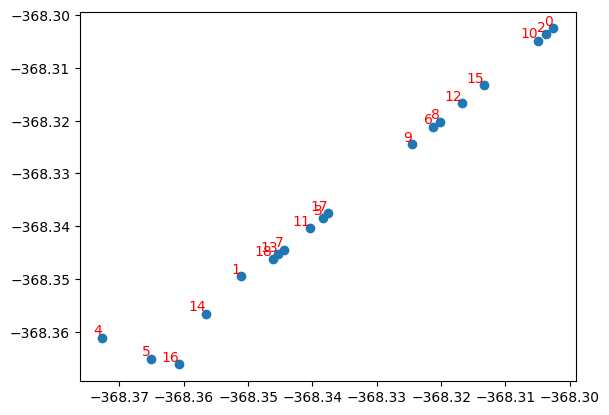

In [132]:
plt.scatter(gt_rewards, gt_rewards_v2)
for i, (x, y) in enumerate(zip(gt_rewards, gt_rewards_v2)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

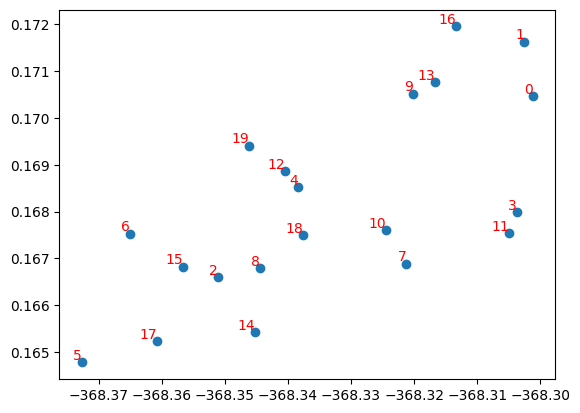

In [ ]:
plt.scatter(gt_rewards, preds)
for i, (x, y) in enumerate(zip(gt_rewards, preds)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

In [124]:
from scipy.stats import spearmanr, pearsonr

spearmanr(gt_rewards, preds)


SignificanceResult(statistic=np.float64(0.7172932330827068), pvalue=np.float64(0.0003711409336667313))

In [125]:
pearsonr(gt_rewards, preds)

PearsonRResult(statistic=np.float64(0.6864949383570004), pvalue=np.float64(0.0008295696820065782))

In [ ]:
gt_rewards = []
gt_rewards_v2 = []
gt_rewards_v3 = []
preds = []

T = 10_000
BS = 1024
total = (12000 - 2100) * BS

for i in range(20):
    path = DIR / f'cfx/{i}.npy'
    reward = np.load(path)
    path = DIR / f'cfx_v2/{i}.npy'
    reward_v2 = np.load(path)
    path = DIR / f'cfx_v3/{i}.npy'
    reward_v3 = np.load(path)
    loss_mask = np.load(DIR / f'cfx_v2/loss_masks_global_{i}.npy')
    print(loss_mask.shape)
    preds.append(np.dot(loss_mask[T*BS:], metagrads[T*BS:]).item())
    gt_rewards.append(reward)
    gt_rewards_v2.append(reward_v2)
    gt_rewards_v3.append(reward_v3)
    #print(preds)
    #print(loss_mask.shape)
    #print(reward)
    print(f'ratio {i}:', (total - loss_mask[2100:].sum()) / total)

(12288000,)
ratio 0: 0.016758601641414142
(12288000,)
ratio 1: 0.0015791706123737374
(12288000,)
ratio 2: 0.0012160669191919192
(12288000,)
ratio 3: 0.0011581636679292929
(12288000,)
ratio 4: 0.0009314827967171717
(12288000,)
ratio 5: 0.00021375868055555555
(12288000,)
ratio 6: 0.8687912326388889
(12288000,)
ratio 7: 0.0009414457070707071
(12288000,)
ratio 8: 0.00043156171085858587
(12288000,)
ratio 9: 0.09129981455176768
(12288000,)
ratio 10: 0.001575915404040404
(12288000,)
ratio 11: 0.002311691130050505
(12288000,)
ratio 12: 0.0003729679608585859
(12288000,)
ratio 13: 0.000588403566919192
(12288000,)
ratio 14: 0.17210464015151516
(12288000,)
ratio 15: 0.0008011758207070707
(12288000,)
ratio 16: 0.00037553267045454543
(12288000,)
ratio 17: 0.9394278724747475
(12288000,)
ratio 18: 0.0003715869633838384
(12288000,)
ratio 19: 0.0004015743371212121


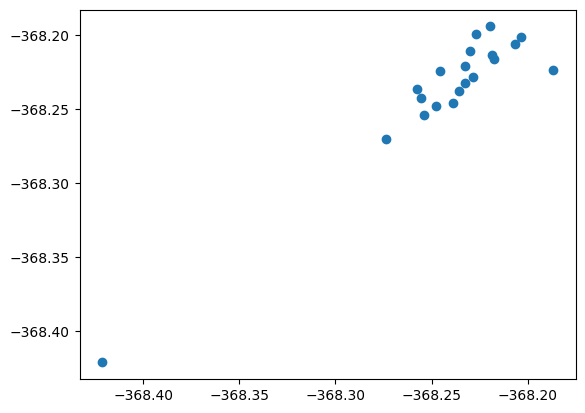

In [108]:
plt.scatter(gt_rewards, gt_rewards_v2)

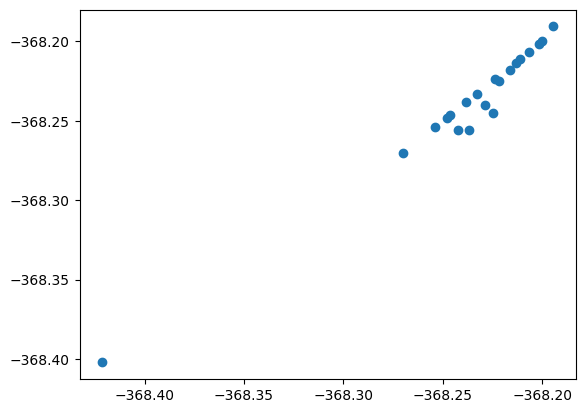

In [118]:
plt.scatter(gt_rewards_v2, gt_rewards_v3)

In [79]:
i = 5
loss_mask = np.load(DIR / f'cfx/loss_masks_global_{i}.npy')

total = (12000 - 2100) * BS
(total - loss_mask[2100:].sum()) / total

np.float64(0.4445624210858586)

In [78]:
for i in range(2100, 12000, 50):
    print(i, loss_mask[i * BS:(i+50) * BS].mean())

2100 0.99890625
2150 0.99912109375
2200 0.99923828125
2250 0.9990234375
2300 0.999140625
2350 0.99888671875
2400 0.99908203125
2450 0.99919921875
2500 0.99923828125
2550 0.99896484375
2600 0.99923828125
2650 0.99904296875
2700 0.99916015625
2750 0.99919921875
2800 0.99908203125
2850 0.99916015625
2900 0.99904296875
2950 0.9990234375
3000 0.99912109375
3050 0.999375
3100 0.99892578125
3150 0.99904296875
3200 0.9988671875
3250 0.99919921875
3300 0.9991796875
3350 0.9989453125
3400 0.9992578125
3450 0.99892578125
3500 0.9988671875
3550 0.99890625
3600 0.9989453125
3650 0.9991796875
3700 0.9988671875
3750 0.99896484375
3800 0.998984375
3850 0.998984375
3900 0.9991015625
3950 0.9992578125
4000 0.99912109375
4050 0.99912109375
4100 0.99916015625
4150 0.99892578125
4200 0.99892578125
4250 0.99908203125
4300 0.99923828125
4350 0.998828125
4400 0.9990234375
4450 0.99912109375
4500 0.99921875
4550 0.99900390625
4600 0.99873046875
4650 0.99904296875
4700 0.99896484375
4750 0.99896484375
4800 0.99

In [98]:
for i in range(20):
    loss_mask = np.load(DIR / f'cfx_v2/loss_masks_global_{i}.npy')
    batch_avg = []
    for j in range(2100, 12000, 50):
        batch_avg.append(loss_mask[j * BS:(j+50) * BS].mean())
    batch_avg = np.array(batch_avg)
    print(i, np.where(batch_avg != 0)[0][0])

0 0
1 0
2 0
3 0
4 0
5 0
6 172
7 0
8 0
9 18
10 0
11 0
12 0
13 0
14 34
15 0
16 0
17 186
18 0
19 0


In [ ]:
np.where(loss_mask != 0)[0] / 1024   # started finetuning from iter 2100

array([ 2100.        ,  2100.00097656,  2100.00195312, ...,
       11999.99707031, 11999.99804688, 11999.99902344], shape=(10133529,))

In [32]:
preds[0]

0.1783645896475376

In [33]:
preds[16]

0.1777739349390674

In [34]:
preds[19]

0.17761674631880336

In [44]:
for i in range(20):
    print(i, preds[i])

0 0.010472665545858462
1 0.010929987942620567
2 0.010946148009715273
3 0.010823110995862972
4 0.010815462422224309
5 0.01089553077856964
6 0.011010907448889995
7 0.010834862848084992
8 0.010874059271948067
9 0.010863849873444131
10 7.60860073643066e-05
11 0.011230986871371584
12 0.010902285130397704
13 0.01109078532911223
14 0.010773821460482447
15 0.011026515270164072
16 0.010965268697253894
17 0.010878734751828656
18 0.010865346661929731
19 0.010871389923091446


In [ ]:
ratio 0: 0.016758601641414142
ratio 4: 0.0009314827967171717
ratio 6: 0.0008281052714646464
ratio 8: 0.00043156171085858587
ratio 9: 0.0004276160037878788
ratio 14: 0.0004661852904040404
ratio 16: 0.00037553267045454543
ratio 17: 0.0005937302714646464
ratio 18: 0.0003715869633838384
ratio 19: 0.0004015743371212121

[0, 4, 6, 8, 9, 14, 16, 17, 18, 19]

In [114]:
gt_rewards = np.array(gt_rewards)
gt_rewards_v2 = np.array(gt_rewards_v2)
preds = np.array(preds)
indices = [0, 1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 15, 16, 18, 19]

(array([1., 0., 0., 0., 0., 0., 1., 4., 7., 7.]),
 array([-368.42126465, -368.39859009, -368.37588501, -368.35321045,
        -368.33050537, -368.30783081, -368.28515625, -368.26245117,
        -368.23977661, -368.21707153, -368.19439697]),
 <BarContainer object of 10 artists>)

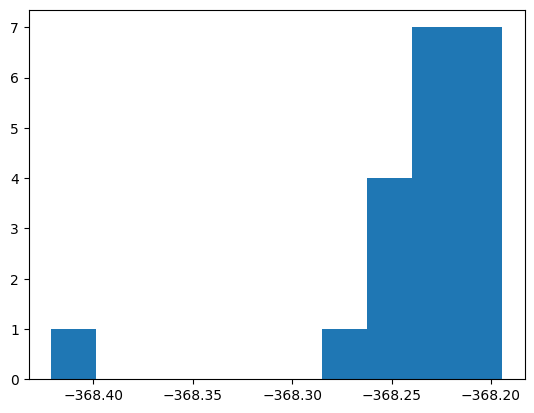

In [104]:
plt.hist(gt_rewards)

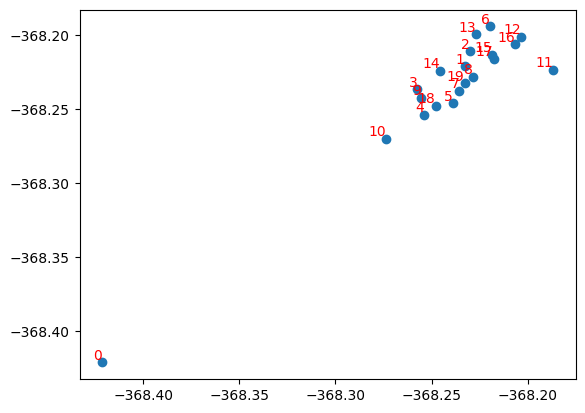

In [116]:
plt.scatter(gt_rewards, gt_rewards_v2)
for i, (x, y) in enumerate(zip(gt_rewards, gt_rewards_v2)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

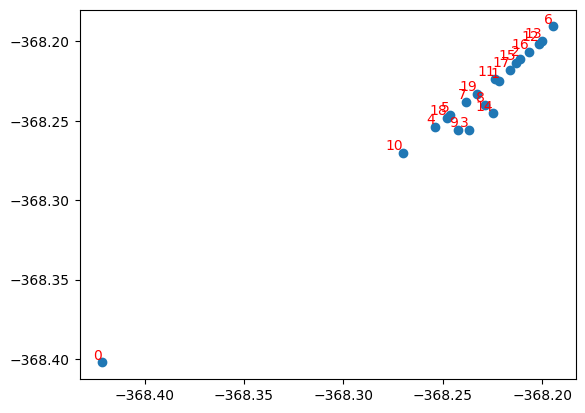

In [119]:
plt.scatter(gt_rewards_v2, gt_rewards_v3)
for i, (x, y) in enumerate(zip(gt_rewards_v2, gt_rewards_v3)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

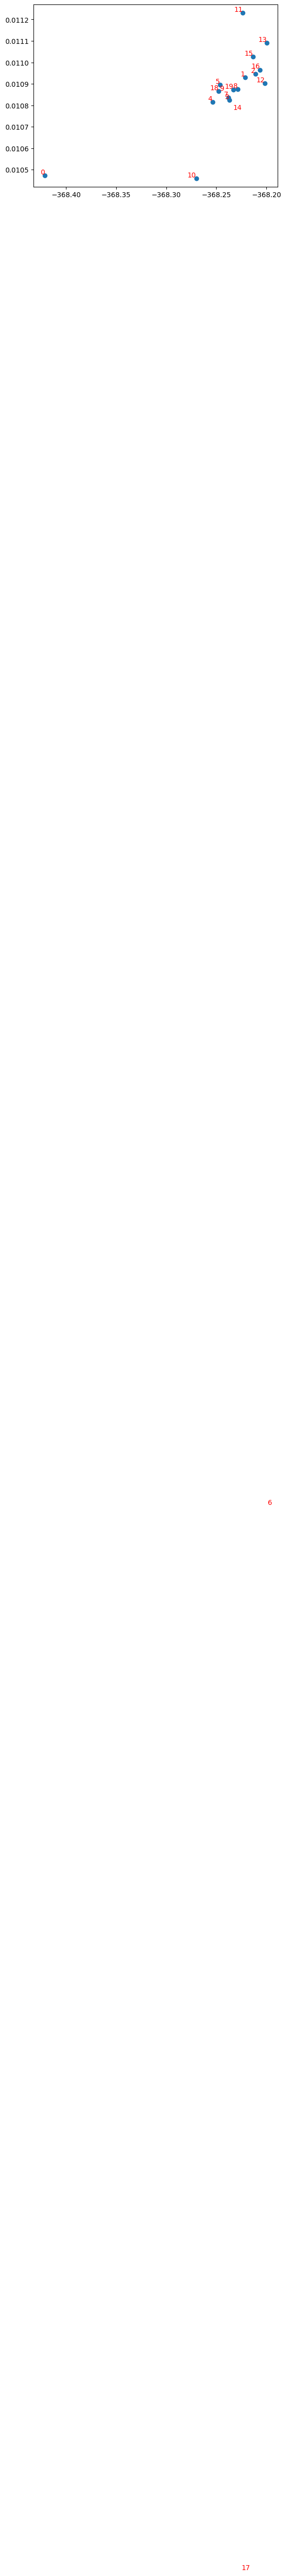

In [115]:
plt.scatter(gt_rewards_v2[indices], preds[indices])
for i, (x, y) in enumerate(zip(gt_rewards_v2, preds)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')